In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 01 — Rolling Window Setup

Partitions the processed dataset into chronological time steps and enumerates all valid (Model A, Model B) window pairs for the rolling-retraining experiment.

**Input:** `data/processed/` (from notebook 00)  
**Output:** `data/windows/window_config.json`

---

**Framework recap (§3.1):**
- Data partitioned into time steps D_{t1}, …, D_{tK} (one per calendar week).
- Training window: W_k = D_{t_{k-L+1}} ∪ … ∪ D_{t_k}  (fixed length L).
- Model A trained on W_k, Model B on W_{k+s}.
- Common evaluation slice: E_{A,B} = D_{t_{k+s+1}} ∪ … ∪ D_{t_{k+s+h}}.

**Parameters used:**
| Parameter | Value | Meaning |
|-----------|-------|--------|
| L | 6 | training window length (weeks) |
| s | 1 | step between windows |
| h | 2 | evaluation horizon (weeks) |
| R | 3 | replicas per window |
| τ | 0.5 | decision threshold |

In [ ]:
import json          # serialising the window configuration to disk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

WORKSPACE = Path('/content/drive/MyDrive/Thesis/Shoppers_workspace')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'
WIN_DIR.mkdir(parents=True, exist_ok=True)  # create output directory if it does not exist yet

# ── Experiment parameters ────────────────────────────────────────────────
L = 6    # training window length (time steps)
S = 1    # step between Model A and Model B windows
H = 2    # evaluation horizon (time steps)
R = 3    # replicas per window
TAU = 0.5  # decision threshold

print(f'Parameters: L={L}, S={S}, H={H}, R={R}, τ={TAU}')

Parameters: L=6, S=1, H=2, R=3, τ=0.5


## 1. Load processed data

In [ ]:
X    = pd.read_parquet(PROC_DIR / 'X.parquet')
Y    = np.load(PROC_DIR / 'Y.npy')
meta = pd.read_parquet(PROC_DIR / 'meta.parquet')

# reset_index gives a clean 0-based integer index; storing it as 'row_idx'
# keeps a stable positional reference so rows can be located with .iloc on
# X and Y even after groupby / merge operations reshape the DataFrame.
meta = meta.reset_index(drop=True)
meta['row_idx'] = meta.index

print(f'X: {X.shape}, Y: {Y.shape}')
print(f'Date range: {meta["offerdate"].min()} → {meta["offerdate"].max()}')

X: (160057, 119), Y: (160057,)
Date range: 2013-03-01 00:00:00 → 2013-04-30 00:00:00


## 2. Define time steps (calendar weeks)

Offers per calendar week:
week
2013-02-25     2924
2013-03-04     1398
2013-03-11    12998
2013-03-18     3334
2013-03-25    45638
2013-04-01    31949
2013-04-08     6423
2013-04-15     6719
2013-04-22    44866
2013-04-29     3808


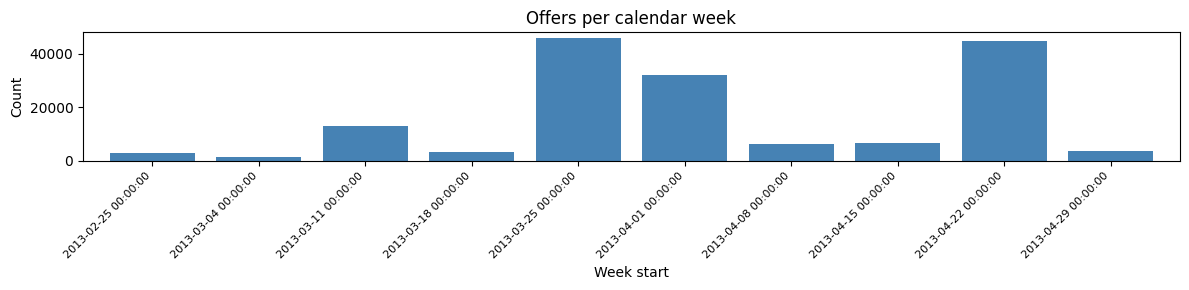

In [ ]:
# dt.to_period('W') maps each date to its ISO calendar-week period;
# .dt.start_time converts that period back to the Monday timestamp that
# anchors the week.  All rows in the same calendar week therefore share
# an identical 'week' value, regardless of the exact day of the offer.
meta['week'] = meta['offerdate'].dt.to_period('W').dt.start_time

# Count offers per week to inspect how the data is distributed over time.
# Highly uneven counts can affect model training stability.
week_counts = meta.groupby('week').size().sort_index()
print('Offers per calendar week:')
print(week_counts.to_string())

fig, ax = plt.subplots(figsize=(12, 3))
week_counts.plot(ax=ax, kind='bar', color='steelblue', width=0.8)
ax.set_title('Offers per calendar week')
ax.set_xlabel('Week start')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(WIN_DIR / 'offers_per_week.png', dpi=120)
plt.show()

In [ ]:
# Sorting gives the canonical temporal ordering t_1 … t_K used throughout
# the experiment.  All step indices below are 0-based (t_1 → 0, t_K → K−1).
time_steps = sorted(week_counts.index.tolist())
K = len(time_steps)
print(f'K = {K} time steps')
for i, ts in enumerate(time_steps):
    n = week_counts[ts]
    print(f'  t_{i+1}: {ts.strftime("%Y-%m-%d")}  ({n:,} offers)')

K = 10 time steps
  t_1: 2013-02-25  (2,924 offers)
  t_2: 2013-03-04  (1,398 offers)
  t_3: 2013-03-11  (12,998 offers)
  t_4: 2013-03-18  (3,334 offers)
  t_5: 2013-03-25  (45,638 offers)
  t_6: 2013-04-01  (31,949 offers)
  t_7: 2013-04-08  (6,423 offers)
  t_8: 2013-04-15  (6,719 offers)
  t_9: 2013-04-22  (44,866 offers)
  t_10: 2013-04-29  (3,808 offers)


In [ ]:
# If certain weeks are very sparse (< 50 offers), merge them with adjacent week
# or switch to biweekly granularity.
MIN_PER_STEP = 50  # minimum offers required to treat a week as its own time step
sparse_weeks = [ts for ts, n in week_counts.items() if n < MIN_PER_STEP]
if sparse_weeks:
    print(f'WARNING: {len(sparse_weeks)} week(s) have < {MIN_PER_STEP} offers: {sparse_weeks}')
    print('Consider switching to biweekly granularity in the parameter cell above.')
else:
    print('All weeks have sufficient offers.')

# Build a lookup dict from week timestamp → 0-based integer step index.
# Mapping this onto meta['step'] allows every row to be addressed by its
# position in the temporal sequence rather than a calendar date.
week_to_step = {w: i for i, w in enumerate(time_steps)}
meta['step'] = meta['week'].map(week_to_step)

All weeks have sufficient offers.


## 3. Enumerate valid window pairs

A pair (A, B) is valid when:
- k ≥ L  (enough history for training window A)
- k + S + H ≤ K − 1  (evaluation slice fits within the data)

where k is the last time step of window A (0-based).

In [ ]:
def get_indices(step_set: set) -> list:
    """Row indices for the given set of time-step indices."""
    return meta[meta['step'].isin(step_set)]['row_idx'].tolist()


pairs = []

# Iterate over every candidate last training step k for Model A.
# Two constraints must both hold:
#   (1) k >= L - 1  →  enough prior steps to fill the L-step training window
#   (2) eval_end = k + S + H < K  →  the evaluation slice fits within the dataset
#
# With K=10, L=6, S=1, H=2:
#   valid k values are 5 and 6  →  2 pairs total
for k in range(L - 1, K):           # k = last step of window A (0-based)
    k_b = k + S                      # last step of window B (shifted S steps forward)
    eval_start = k_b + 1             # first evaluation step (immediately after B's window)
    eval_end   = k_b + H             # last evaluation step (H steps after eval_start - 1)

    if eval_end >= K:
        break                        # not enough future data for a complete evaluation slice

    # Time-step sets
    steps_A    = set(range(k - L + 1, k + 1))        # W_k:     L steps ending at k
    steps_B    = set(range(k_b - L + 1, k_b + 1))    # W_{k+s}: L steps ending at k+s
    steps_eval = set(range(eval_start, eval_end + 1)) # E_{A,B}: H steps starting after B

    # Row index lists — used directly as positional selectors on X and Y
    idx_A    = get_indices(steps_A)
    idx_B    = get_indices(steps_B)
    idx_eval = get_indices(steps_eval)

    if len(idx_eval) == 0:
        print(f'Skipping pair k={k}: empty evaluation slice')
        continue

    pairs.append({
        'pair_id':    len(pairs),
        'k':          k,
        'k_b':        k_b,
        'step_label_A':   time_steps[k].strftime('%Y-%m-%d'),
        'step_label_B':   time_steps[k_b].strftime('%Y-%m-%d'),
        'eval_start_label': time_steps[eval_start].strftime('%Y-%m-%d'),
        'eval_end_label':   time_steps[eval_end].strftime('%Y-%m-%d'),
        'steps_A':    sorted(steps_A),
        'steps_B':    sorted(steps_B),
        'steps_eval': sorted(steps_eval),
        'idx_A':      idx_A,
        'idx_B':      idx_B,
        'idx_eval':   idx_eval,
        'n_train_A':  len(idx_A),
        'n_train_B':  len(idx_B),
        'n_eval':     len(idx_eval),
    })

print(f'\nTotal valid window pairs: {len(pairs)}')


Total valid window pairs: 2


In [ ]:
# Summary table: one row per valid pair.
# 'A_window' / 'B_window' show the last week of each model's training window
# (the full window spans the preceding L-1 weeks as well).
# 'eval_period' is the shared held-out slice used to compare both models.
summary = pd.DataFrame([{
    'pair_id':  p['pair_id'],
    'A_window': f"{p['step_label_A']}",
    'B_window': f"{p['step_label_B']}",
    'eval_period': f"{p['eval_start_label']} → {p['eval_end_label']}",
    'n_train_A': p['n_train_A'],
    'n_train_B': p['n_train_B'],
    'n_eval':    p['n_eval'],
} for p in pairs])

print(summary.to_string(index=False))

# Check for empty evaluation slices — these must not exist
empty_eval = summary[summary['n_eval'] == 0]
if not empty_eval.empty:
    print(f'\nWARNING: {len(empty_eval)} pairs with empty evaluation slice!')
else:
    print('\nAll evaluation slices are non-empty.')

 pair_id   A_window   B_window             eval_period  n_train_A  n_train_B  n_eval
       0 2013-04-01 2013-04-08 2013-04-15 → 2013-04-22      98241     101740   51585
       1 2013-04-08 2013-04-15 2013-04-22 → 2013-04-29     101740     107061   48674

All evaluation slices are non-empty.


## 4. Verify non-overlap of evaluation slices

For a fair experiment the evaluation slice must chronologically follow both training windows.

In [ ]:
for p in pairs:
    # Evaluation steps must not overlap with either training window —
    # overlap would constitute data leakage from the evaluation period into training.
    assert not set(p['steps_eval']) & set(p['steps_A']), f"Pair {p['pair_id']}: eval overlaps A!"
    assert not set(p['steps_eval']) & set(p['steps_B']), f"Pair {p['pair_id']}: eval overlaps B!"
    # The earliest evaluation step must come strictly after B's last training step,
    # guaranteeing temporal ordering: train A → train B → evaluate (no future peeking).
    assert min(p['steps_eval']) > max(p['steps_B']), f"Pair {p['pair_id']}: eval not after B!"

print('Non-overlap checks passed for all pairs.')

Non-overlap checks passed for all pairs.


## 5. Save window configuration

In [ ]:
# The JSON captures everything needed to reproduce the experiment downstream:
#   'parameters' — scalar hyperparameters (L, S, H, R, TAU) and the
#                  ordered list of week labels that define the time axis.
#   'pairs'      — one entry per valid (A, B) pair, each containing:
#                    * integer step indices and human-readable date labels
#                    * pre-computed row index lists (idx_A, idx_B, idx_eval)
#                      that can be used directly with .iloc on X and Y in
#                      subsequent notebooks without re-running this setup.
config = {
    'parameters': {
        'L': L, 'S': S, 'H': H, 'R': R, 'TAU': TAU,
        'K': K,
        'time_steps': [ts.strftime('%Y-%m-%d') for ts in time_steps],
    },
    'pairs': pairs
}

out_path = WIN_DIR / 'window_config.json'
with open(out_path, 'w') as f:
    json.dump(config, f, indent=2)

size_kb = out_path.stat().st_size / 1024
print(f'Saved {out_path.name} ({size_kb:.0f} KB)')
print(f'{len(pairs)} window pairs, {K} time steps')

Saved window_config.json (7609 KB)
2 window pairs, 10 time steps


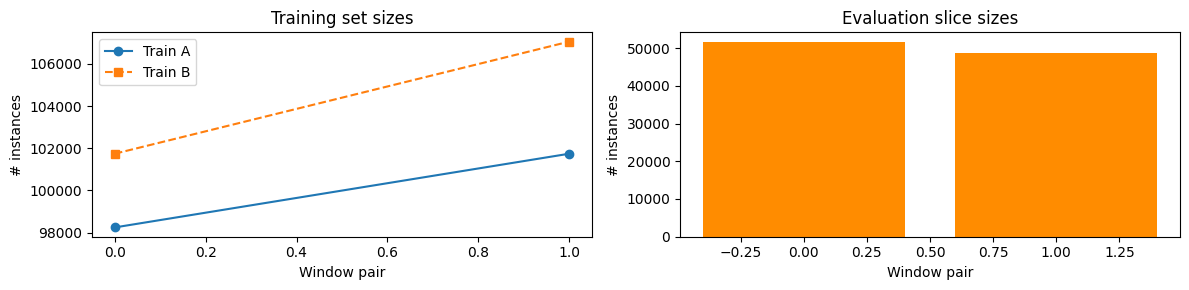

Done.


In [ ]:
# Visual: training and eval set sizes over time.
# Left plot  — Train A vs Train B sample counts per pair.
#              B's window is offset by S steps, so it should overlap heavily
#              with A but include slightly newer data; sizes should be similar.
# Right plot — Evaluation slice size per pair.
#              Large drops would signal data gaps in the later weeks.
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

pair_ids = [p['pair_id'] for p in pairs]
axes[0].plot(pair_ids, [p['n_train_A'] for p in pairs], 'o-', label='Train A')
axes[0].plot(pair_ids, [p['n_train_B'] for p in pairs], 's--', label='Train B')
axes[0].set_title('Training set sizes')
axes[0].set_xlabel('Window pair')
axes[0].set_ylabel('# instances')
axes[0].legend()

axes[1].bar(pair_ids, [p['n_eval'] for p in pairs], color='darkorange')
axes[1].set_title('Evaluation slice sizes')
axes[1].set_xlabel('Window pair')
axes[1].set_ylabel('# instances')

plt.tight_layout()
plt.savefig(WIN_DIR / 'window_sizes.png', dpi=120)
plt.show()
print('Done.')